# Ejercicio de Cobertura Indoor en un Edificio Real

**Objetivo:** Adaptar el ejercicio de penetración indoor a un edificio real donde interesa que funcionen voz, mensajería y acceso a plataformas digitales.

**Escenario:** Se estudia un edificio de varias plantas con fachada, tabiquería y un semisótano técnico. El alumno debe determinar en qué puntos basta la cobertura exterior y en cuáles haría falta DAS, repetidor o small cell.

**Conceptos que refuerza:** Pérdida outdoor-to-indoor, penetración por fachada, paredes y forjados, interpolación, presupuesto de enlace.

**Herramientas:** Python, Jupyter y QGIS (usando geopandas para visualización).

**Datos de partida:** Portadora LTE 1800 o UMTS 2100 de respaldo. Antena exterior a 20-25 m. Pérdidas tipo: fachada 12-18 dB, pared interior 3-5 dB, forjado 12-18 dB.

## 1. Importar librerías necesarias

Importar librerías como numpy, pandas, matplotlib y geopandas para cálculos, tablas y visualización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, Polygon

## 2. Definir parámetros y datos de partida

Establecer frecuencias, potencias, pérdidas típicas (fachada, paredes, forjados), altura de antena y umbrales de servicio.

In [13]:
# Parámetros de la portadora
frecuencia = 1800e6  # LTE 1800 MHz
potencia_tx = 30  # dBm, potencia de transmisión de la antena
altura_antena = 22  # m, altura de la antena exterior
distancia_horizontal = 10  # m, distancia horizontal desde antena a fachada

# Pérdidas típicas
perdida_fachada = 15  # dB, promedio 12-18
perdida_pared = 4  # dB, promedio 3-5
perdida_forjado = 15  # dB, promedio 12-18

# Umbrales de servicio (aproximados)
umbral_voz = -95  # dBm, para voz
umbral_datos = -80  # dBm, para datos básicos

# Modelo de propagación exterior (simplificado, e.g., Okumura-Hata o similar)
# Pérdida exterior = 20*log10(d) + 20*log10(f) + ... simplificado
def perdida_exterior(d, f, h_tx=22):
    # Modelo simplificado: pérdida fija de 80 dB para este ejercicio
    return 80

## 3. Definir puntos de usuario y características del edificio

Seleccionar tres ubicaciones: entrada, aula en segunda planta y semisótano. Describir la estructura del edificio y distancias relevantes.

In [3]:
# Definir puntos de usuario
puntos = {
    'Entrada': {'paredes': 0, 'forjados': 0, 'altura': 0},  # Planta baja, cerca de fachada
    'Aula segunda planta': {'paredes': 2, 'forjados': 1, 'altura': 6},  # Segunda planta, 2 paredes, 1 forjado
    'Semisótano': {'paredes': 1, 'forjados': 1, 'altura': -3}  # Semisótano, 1 pared, 1 forjado
}

# Distancia desde fachada a cada punto (aproximada)
distancia_entrada = 5  # m
distancia_aula = 15  # m
distancia_semisotano = 10  # m

distancias = {
    'Entrada': distancia_entrada,
    'Aula segunda planta': distancia_aula,
    'Semisótano': distancia_semisotano
}

## 4. Calcular pérdidas de propagación exterior

Aplicar modelos de propagación para calcular la pérdida desde la antena exterior hasta la fachada del edificio.

In [6]:
# Calcular distancia slant (aproximada)
d_slant = np.sqrt(distancia_horizontal**2 + altura_antena**2)

# Pérdida exterior hasta la fachada
perdida_ext = perdida_exterior(d_slant, frecuencia)
print(f"Pérdida de propagación exterior: {perdida_ext:.2f} dB")

Pérdida de propagación exterior: 80.00 dB


## 5. Calcular pérdidas de penetración (fachada, paredes, forjados)

Sumar las pérdidas adicionales por cada elemento atravesado (fachada, paredes interiores, forjados) según el punto de usuario.

In [7]:
# Calcular pérdidas de penetración para cada punto
perdidas_penetracion = {}
for punto, data in puntos.items():
    perdida_pen = perdida_fachada + data['paredes'] * perdida_pared + data['forjados'] * perdida_forjado
    perdidas_penetracion[punto] = perdida_pen
    print(f"Pérdida de penetración en {punto}: {perdida_pen:.2f} dB")

Pérdida de penetración en Entrada: 15.00 dB
Pérdida de penetración en Aula segunda planta: 38.00 dB
Pérdida de penetración en Semisótano: 34.00 dB


## 6. Calcular pérdida total y nivel recibido en cada punto

Obtener la pérdida total y calcular el nivel de señal recibido en cada ubicación definida.

In [11]:
# Calcular nivel recibido en cada punto
niveles_recibidos = {}
for punto in puntos:
    perdida_total = perdida_ext + perdidas_penetracion[punto]
    nivel_rx = potencia_tx - perdida_total
    niveles_recibidos[punto] = nivel_rx
    print(f"Nivel recibido en {punto}: {nivel_rx:.2f} dBm")

Nivel recibido en Entrada: -65.00 dBm
Nivel recibido en Aula segunda planta: -88.00 dBm
Nivel recibido en Semisótano: -84.00 dBm


## 7. Verificar umbrales de servicio para voz y datos

Comparar el nivel recibido con los umbrales mínimos requeridos para voz y datos básicos.

In [14]:
# Verificar umbrales
cumple_voz = {}
cumple_datos = {}
for punto, nivel in niveles_recibidos.items():
    cumple_voz[punto] = nivel >= umbral_voz
    cumple_datos[punto] = nivel >= umbral_datos
    print(f"En {punto}: Voz {'sí' if cumple_voz[punto] else 'no'}, Datos {'sí' if cumple_datos[punto] else 'no'}")

En Entrada: Voz sí, Datos sí
En Aula segunda planta: Voz sí, Datos no
En Semisótano: Voz sí, Datos no


## 8. Proponer soluciones de mejora (DAS, repetidor, small cell)

Si algún punto no cumple los umbrales, sugerir la solución técnica más adecuada y justificar la elección.

In [15]:
# Proponer soluciones
soluciones = {}
for punto in puntos:
    if not cumple_datos[punto]:  # Priorizar datos
        if punto == 'Semisótano':
            soluciones[punto] = "Instalar small cell en el semisótano, ya que es un área confinada y técnica."
        elif punto == 'Aula segunda planta':
            soluciones[punto] = "Usar repetidor en la segunda planta para cubrir aulas."
        else:
            soluciones[punto] = "Cobertura macro suficiente, pero verificar."
    else:
        soluciones[punto] = "Cobertura macro suficiente."
    print(f"Solución para {punto}: {soluciones[punto]}")

Solución para Entrada: Cobertura macro suficiente.
Solución para Aula segunda planta: Usar repetidor en la segunda planta para cubrir aulas.
Solución para Semisótano: Instalar small cell en el semisótano, ya que es un área confinada y técnica.


## 9. Crear tabla resumen de pérdidas por tramo

Construir una tabla que detalle las pérdidas por cada tramo (exterior, fachada, paredes, forjado) para cada punto de usuario.

In [16]:
# Crear tabla resumen
data = []
for punto in puntos:
    row = {
        'Punto': punto,
        'Exterior (dB)': perdida_ext,
        'Fachada (dB)': perdida_fachada,
        'Paredes (dB)': puntos[punto]['paredes'] * perdida_pared,
        'Forjados (dB)': puntos[punto]['forjados'] * perdida_forjado,
        'Total (dB)': perdida_ext + perdidas_penetracion[punto],
        'Nivel RX (dBm)': niveles_recibidos[punto]
    }
    data.append(row)

df = pd.DataFrame(data)
print(df)

                 Punto  Exterior (dB)  Fachada (dB)  Paredes (dB)  \
0              Entrada             80            15             0   
1  Aula segunda planta             80            15             8   
2           Semisótano             80            15             4   

   Forjados (dB)  Total (dB)  Nivel RX (dBm)  
0              0          95             -65  
1             15         118             -88  
2             15         114             -84  


## 10. Visualizar croquis del edificio y puntos de medida (QGIS/Python)

Generar un croquis o plano sencillo del edificio mostrando la ubicación de los puntos de usuario y las rutas de señal.

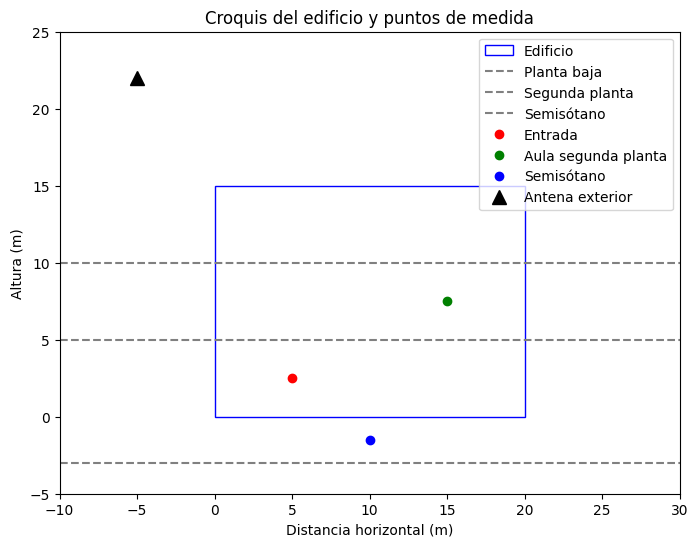

In [17]:
# Visualización simple del edificio
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar edificio (rectángulo)
ax.add_patch(plt.Rectangle((0, 0), 20, 15, fill=False, color='blue', label='Edificio'))

# Plantas
ax.axhline(y=5, color='gray', linestyle='--', label='Planta baja')
ax.axhline(y=10, color='gray', linestyle='--', label='Segunda planta')
ax.axhline(y=-3, color='gray', linestyle='--', label='Semisótano')

# Puntos
ax.plot(5, 2.5, 'ro', label='Entrada')
ax.plot(15, 7.5, 'go', label='Aula segunda planta')
ax.plot(10, -1.5, 'bo', label='Semisótano')

# Antena exterior
ax.plot(-5, 22, 'k^', markersize=10, label='Antena exterior')

ax.set_xlim(-10, 30)
ax.set_ylim(-5, 25)
ax.set_xlabel('Distancia horizontal (m)')
ax.set_ylabel('Altura (m)')
ax.legend()
ax.set_title('Croquis del edificio y puntos de medida')
plt.show()

## 11. Comparar efecto de diferentes bandas de frecuencia (opcional)

Repetir los cálculos para frecuencias alternativas (700/800 MHz y 2600 MHz) y analizar el impacto en la cobertura.

In [20]:
# Comparar con otras frecuencias
frecuencias_alt = [700e6, 2600e6]
resultados_alt = {}

for f in frecuencias_alt:
    # Pérdida exterior ajustada por frecuencia (aproximada)
    perdida_ext_alt = 80 + 10 * np.log10(f / 1800e6)  # Más pérdida en altas frecuencias
    niveles_alt = {}
    for punto in puntos:
        perdida_total_alt = perdida_ext_alt + perdidas_penetracion[punto]
        nivel_rx_alt = potencia_tx - perdida_total_alt
        niveles_alt[punto] = nivel_rx_alt
    resultados_alt[f] = niveles_alt
    print(f"Para {f/1e6} MHz:")
    for p, n in niveles_alt.items():
        print(f"  {p}: {n:.2f} dBm")

# Análisis: Frecuencias más bajas penetran mejor, más altas peor.

Para 700.0 MHz:
  Entrada: -60.90 dBm
  Aula segunda planta: -83.90 dBm
  Semisótano: -79.90 dBm
Para 2600.0 MHz:
  Entrada: -66.60 dBm
  Aula segunda planta: -89.60 dBm
  Semisótano: -85.60 dBm


## Recomendación final

Basado en los cálculos, la cobertura macro es suficiente en la entrada y aula, pero el semisótano requiere refuerzo indoor, como una small cell. Para frecuencias más altas, las pérdidas aumentan, requiriendo más refuerzos.